<a href="https://colab.research.google.com/github/Rakesh-562/ScoreStats/blob/main/Topsis_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import pandas as pd
import numpy as np

In [81]:
bat=pd.read_csv("batting_stats_for_icc_mens_t20_world_cup_2024.csv")
bowl=pd.read_csv("bowling_stats_for_icc_mens_t20_world_cup_2024.csv")
wk=pd.read_csv("wk_stats_for_icc_mens_t20_world_cup_2024.csv")
# bat.head()
# bowl.head()
# wk.head()

In [82]:
team_name="India"
ind_bat=bat[bat["Team"]==team_name]
ind_bowl=bowl[bowl["Team"]==team_name]
ind_wk=wk[wk["Team"]==team_name]
ind_wk

,Player,Team,Mat,Inns,Dis,Ct,St,Max Dis Inns,Dis/Inn
0,RR Pant,India,8,8,14,13,1,3,1.75


In [83]:
# normalize helper
def normalize(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

# Available columns: ['Ave', 'SR', '100', '50']
ind_bat["avg_norm"] = normalize(ind_bat["Ave"])
ind_bat["sr_norm"] = normalize(ind_bat["SR"])
ind_bat["milestone_score"] = normalize(ind_bat["50"] + 2 * ind_bat["100"])

# New composite batting index based on available data
ind_bat["batting_index"] = (
    0.40 * ind_bat["avg_norm"] +
    0.40 * ind_bat["sr_norm"] +
    0.20 * ind_bat["milestone_score"]
)

print("Batting Index calculated successfully.")
ind_bat[['Player', 'Ave', 'SR', "batting_index"]].sort_values(by="batting_index", ascending=False).head(10)

Batting Index calculated successfully.


/tmp/ipykernel_923/2172161516.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_bat["avg_norm"] = normalize(ind_bat["Ave"])
/tmp/ipykernel_923/2172161516.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_bat["sr_norm"] = normalize(ind_bat["SR"])
/tmp/ipykernel_923/2172161516.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

,Player,Ave,SR,batting_index
202,RG Sharma,36.71,156.70,0.899907
164,HH Pandya,48.00,151.57,0.847759
244,SA Yadav,28.42,135.37,0.710527
167,AR Patel,23.00,139.39,0.542135
165,RR Pant,24.42,127.61,0.524350
106,V Kohli,18.87,112.68,0.507228
86,RA Jadeja,11.66,159.09,0.497167
55,S Dube,22.16,114.65,0.472931
15,Arshdeep Singh,12.00,75.00,0.288573
140,Mohammed Siraj,0.00,100.00,0.251430


In [84]:
print("Available batting columns:", ind_bat.columns.tolist())
ind_bat.head()

Available batting columns: ['Player', 'Team', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'SR', '100', '50', '0', 'avg_norm', 'sr_norm', 'milestone_score', 'batting_index']


,Player,Team,Mat,Inns,NO,Runs,HS,Ave,SR,100,50,0,avg_norm,sr_norm,milestone_score,batting_index
15,Arshdeep Singh,India,8,3,2,12,9,12.00,75.00,0,0,0,0.250000,0.471431,0.000000,0.288573
35,JJ Bumrah,India,8,1,0,0,0,0.00,0.00,0,0,1,0.000000,0.000000,0.000000,0.000000
55,S Dube,India,8,8,2,133,34,22.16,114.65,0,0,1,0.461667,0.720661,0.000000,0.472931
86,RA Jadeja,India,8,5,2,35,17*,11.66,159.09,0,0,1,0.242917,1.000000,0.000000,0.497167
106,V Kohli,India,8,8,0,151,76,18.87,112.68,0,1,2,0.393125,0.708278,0.333333,0.507228


In [85]:
# Calculate bowling index using inverse of Runs and Econ, plus Wickets
ind_bowl["runs_inv_norm"] = 1 - normalize(ind_bowl["Runs"])
ind_bowl["eco_inv_norm"] = 1 - normalize(ind_bowl["Econ"])
ind_bowl["wkts_norm"] = normalize(ind_bowl["Wkts"])

# Composite Bowling Index
# Giving weight to economy, run control, and wicket taking
ind_bowl["bowling_index"] = (
    0.40 * ind_bowl["wkts_norm"] +
    0.30 * ind_bowl["eco_inv_norm"] +
    0.30 * ind_bowl["runs_inv_norm"]
)

print("Bowling Index calculated successfully.")
ind_bowl[['Player', 'Wkts', 'Econ', 'Runs', 'bowling_index']].sort_values(by='bowling_index', ascending=False).head(10)
ind_bowl

Bowling Index calculated successfully.


/tmp/ipykernel_923/1179871155.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_bowl["runs_inv_norm"] = 1 - normalize(ind_bowl["Runs"])
/tmp/ipykernel_923/1179871155.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_bowl["eco_inv_norm"] = 1 - normalize(ind_bowl["Econ"])
/tmp/ipykernel_923/1179871155.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

,Player,Team,Mat,Inns,Balls,Mdns,Runs,Wkts,BBI,Ave,Econ,SR,5,10,Ct,runs_inv_norm,eco_inv_norm,wkts_norm,bowling_index
11,Arshdeep Singh,India,8,8,180,0,215,17,9-Apr,12.64,7.16,10.5,0,0,3,0.000000,0.562225,1.000000,0.568668
23,JJ Bumrah,India,8,8,178,2,124,15,7-Mar,8.26,4.17,11.8,0,0,2,0.446078,1.000000,0.882353,0.786765
33,S Dube,India,8,1,6,0,11,0,-,0.00,11.00,-,0,0,1,1.000000,0.000000,0.000000,0.300000
55,RA Jadeja,India,8,7,84,0,106,1,20-Jan,106.00,7.57,84,0,0,3,0.534314,0.502196,0.058824,0.334482
68,Kuldeep Yadav,India,5,5,120,0,139,10,19-Mar,13.90,6.95,12,0,0,2,0.372549,0.592972,0.588235,0.524950
91,Mohammed Siraj,India,3,3,66,0,57,1,13-Jan,57.00,5.18,66,0,0,2,0.774510,0.852123,0.058824,0.511519
106,HH Pandya,India,8,8,150,2,191,11,20-Mar,17.36,7.64,13.6,0,0,2,0.117647,0.491947,0.647059,0.441702
108,AR Patel,India,8,8,132,1,173,9,23-Mar,19.22,7.86,14.6,0,0,4,0.205882,0.459736,0.529412,0.411450


In [115]:
ind_wk["is_wk"] = 1
# Identify wicketkeepers by name
wk_player_names = ind_wk['Player'].tolist()

# Remove any entries from ind_bat that are also in ind_wk, to avoid duplicates
# We will prioritize the ind_wk entry for players who are WKs
ind_bat_filtered = ind_bat[~ind_bat['Player'].isin(wk_player_names)].copy()

# Ensure ind_wk has necessary batting columns, filled with NaN where data isn't available
# and set is_wk to 1. This ensures a clean concatenation.
ind_wk_for_concat = ind_wk.copy()
for col in ['Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'SR', '100', '50', '0', 'avg_norm', 'sr_norm', 'milestone_score', 'batting_index']:
    if col not in ind_wk_for_concat.columns:
        ind_wk_for_concat[col] = np.nan
ind_wk_for_concat["is_wk"] = 1

# Concatenate the filtered ind_bat with the prepared ind_wk
ind_bat = pd.concat([ind_bat_filtered, ind_wk_for_concat], ignore_index=True)

# Fill any remaining NaN in batting_index (e.g., for WKs whose batting stats might be missing in original bat data)
ind_bat["batting_index"] = ind_bat["batting_index"].fillna(0)

print("Corrected ind_bat (unique players, is_wk assigned):")
ind_bat.sort_values(by='Player', inplace=True)
ind_bat

Corrected ind_bat (unique players, is_wk assigned):


/tmp/ipykernel_923/4016667591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_wk["is_wk"] = 1


,Player,Team,Mat,Inns,NO,Runs,HS,Ave,SR,100,...,sr_norm,milestone_score,batting_index,is_wk,Dis,Ct,St,Max Dis Inns,Dis/Inn,score
3,AR Patel,India,8,5,1.0,92.0,47,23.00,139.39,0.0,...,0.876171,0.000000,0.542135,0,NaN,NaN,NaN,NaN,NaN,0.594055
7,Arshdeep Singh,India,8,3,2.0,12.0,9,12.00,75.00,0.0,...,0.471431,0.000000,0.288573,0,NaN,NaN,NaN,NaN,NaN,0.323489
0,HH Pandya,India,8,6,3.0,144.0,50*,48.00,151.57,0.0,...,0.952731,0.333333,0.847759,0,NaN,NaN,NaN,NaN,NaN,0.956808
9,JJ Bumrah,India,8,1,0.0,0.0,0,0.00,0.00,0.0,...,0.000000,0.000000,0.000000,0,NaN,NaN,NaN,NaN,NaN,0.000000
8,Mohammed Siraj,India,3,1,1.0,7.0,7*,0.00,100.00,0.0,...,0.628575,0.000000,0.251430,0,NaN,NaN,NaN,NaN,NaN,0.284697
6,RA Jadeja,India,8,5,2.0,35.0,17*,11.66,159.09,0.0,...,1.000000,0.000000,0.497167,0,NaN,NaN,NaN,NaN,NaN,0.507498
1,RG Sharma,India,8,8,1.0,257.0,92,36.71,156.70,0.0,...,0.984977,1.000000,0.899907,0,NaN,NaN,NaN,NaN,NaN,0.863452
10,RR Pant,India,8,8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,1,14.0,13.0,1.0,3.0,1.75,NaN
4,S Dube,India,8,8,2.0,133.0,34,22.16,114.65,0.0,...,0.720661,0.000000,0.472931,0,NaN,NaN,NaN,NaN,NaN,0.532678
2,SA Yadav,India,8,8,1.0,199.0,53,28.42,135.37,0.0,...,0.850902,0.666667,0.710527,0,NaN,NaN,NaN,NaN,NaN,0.713208


In [117]:
# Recalculate batting index on the combined 'ind_bat' dataframe to ensure it exists
ind_bat['Ave'] = ind_bat['Ave'].fillna(0)
ind_bat['SR'] = ind_bat['SR'].fillna(0)
ind_bat['100'] = ind_bat['100'].fillna(0)
ind_bat['50'] = ind_bat['50'].fillna(0)

ind_bat["avg_norm"] = normalize(ind_bat["Ave"])
ind_bat["sr_norm"] = normalize(ind_bat["SR"])
ind_bat["milestone_score"] = normalize(ind_bat["50"] + 2 * ind_bat["100"])

ind_bat["batting_index"] = (
    0.40 * ind_bat["avg_norm"] +
    0.40 * ind_bat["sr_norm"] +
    0.20 * ind_bat["milestone_score"]

)
# Now extract the matrices
bat_matrix = ind_bat[["batting_index", "Ave", "SR"]].fillna(0)
bowl_matrix = ind_bowl[["bowling_index", "Econ", "Wkts"]].fillna(0)

print("Matrices created successfully.")
print("Batting Matrix shape:", bat_matrix.shape)
print("Bowling Matrix shape:", bowl_matrix.shape)

Matrices created successfully.
Batting Matrix shape: (11, 3)
Bowling Matrix shape: (8, 3)


In [88]:
def topsis(matrix, weights):
    matrix = matrix.values.astype(float)

    # Step 1: Normalize
    norm = matrix / np.sqrt((matrix**2).sum(axis=0))

    # Step 2: Weighted matrix
    weighted = norm * weights

    # Step 3: Ideal best & worst
    ideal_best = weighted.max(axis=0)
    ideal_worst = weighted.min(axis=0)

    # Step 4: Distance
    d_pos = np.sqrt(((weighted - ideal_best)**2).sum(axis=1))
    d_neg = np.sqrt(((weighted - ideal_worst)**2).sum(axis=1))

    # Step 5: Score
    score = d_neg / (d_pos + d_neg)

    return score

In [118]:
# Adjusting weights to match the 3 columns in our matrices
bat_weights = np.array([0.4, 0.3, 0.3])
bowl_weights = np.array([0.4, 0.3, 0.3])

ind_bat["score"] = topsis(bat_matrix, bat_weights)
ind_bowl["score"] = topsis(bowl_matrix, bowl_weights)

print("TOPSIS scores calculated successfully.")

TOPSIS scores calculated successfully.


In [119]:
ind_bat = ind_bat.sort_values(by="score", ascending=False)
ind_bowl = ind_bowl.sort_values(by="score", ascending=False)

In [120]:
from typing_extensions import final
selected_players = set()

final_team = []

# 1️⃣ Select Wicketkeeper
wk_player = ind_bat[ind_bat["is_wk"] == 1].sort_values(by="score", ascending=False)

for _, row in wk_player.iterrows():
    if row["Player"] not in selected_players:
        final_team.append(row["Player"]) # Append player name
        selected_players.add(row["Player"])
        break

print(f"Selected Wicketkeeper: {final_team[-1]}")

Selected Wicketkeeper: RR Pant


In [121]:
batsmen_pool = ind_bat[ind_bat["is_wk"] == 0].sort_values(by="score", ascending=False)

# Keep selecting batsmen until 5 total players (1 WK + 4 batsmen)
for _, row in batsmen_pool.iterrows():
    if len(final_team) >= 5:
        break
    if row["Player"] not in selected_players:
        final_team.append(row["Player"]) # Append player name
        selected_players.add(row["Player"])

print(f"Selected {len(final_team) - 1} Batsmen.")

Selected 4 Batsmen.


In [122]:
bowlers_pool = ind_bowl.sort_values(by="bowling_index", ascending=False)

# Keep selecting bowlers until 8 total players (1 WK + 4 batsmen + 3 bowlers)
for _, row in bowlers_pool.iterrows():
    if len(final_team) >= 8:
        break
    if row["Player"] not in selected_players:
        final_team.append(row["Player"]) # Append player name
        selected_players.add(row["Player"])

print(f"Selected {len(final_team) - 5} Bowlers.")

Selected 3 Bowlers.


In [127]:
allrounders = pd.merge(ind_bat, ind_bowl, on="Player", suffixes=('_bat', '_bowl'))

# Combine both scores for allrounders in the comprehensive allrounders dataframe
allrounders["final_score"] = 0.6 * allrounders["batting_index"] + 0.4 * allrounders["bowling_index"]

allrounders = allrounders.sort_values(by="final_score", ascending=False)

print(f"Players selected so far: {len(final_team)}")
for _, row in allrounders.iterrows():
    if len(final_team) >= 11: # Ensure a total of 11 players are selected
        break
    if row["Player"] not in selected_players:
        final_team.append(row["Player"]) # Append player name
        selected_players.add(row["Player"])

# Create a master DataFrame by merging ind_bat and ind_bowl to get full stats for all possible players
# Use 'left_on' and 'right_on' to handle cases where 'Player' column might have slight differences if not directly merged
master_player_df = pd.merge(ind_bat, ind_bowl, on='Player', how='outer', suffixes=('_bat', '_bowl'))

# Filter master_player_df to get data for only the final_team players
final_xi_df = master_player_df[master_player_df['Player'].isin(final_team)]

# Sort final_xi_df based on the order of players in final_team list for consistency
final_xi_df['Player'] = pd.Categorical(final_xi_df['Player'], categories=final_team, ordered=True)
final_xi_df = final_xi_df.sort_values('Player')

print("Columns in final_xi_df before display:", final_xi_df.columns.tolist())
print("Final Team (11 players) selected:")
display(final_xi_df[['Player', 'Team_bat', 'is_wk', 'batting_index', 'bowling_index']].head(11))

# Now, filter to get only the batsmen from the final_xi_df
# Batsmen are players who are not wicketkeepers (is_wk == 0)
selected_batsmen_only = final_xi_df[final_xi_df["is_wk"] == 0]
print("\nSelected Batsmen Only:")
display(selected_batsmen_only[['Player', 'Team_bat', 'batting_index']])

Players selected so far: 8
Columns in final_xi_df before display: ['Player', 'Team_bat', 'Mat_bat', 'Inns_bat', 'NO', 'Runs_bat', 'HS', 'Ave_bat', 'SR_bat', '100', '50', '0', 'avg_norm', 'sr_norm', 'milestone_score', 'batting_index', 'is_wk', 'Dis', 'Ct_bat', 'St', 'Max Dis Inns', 'Dis/Inn', 'score_bat', 'Team_bowl', 'Mat_bowl', 'Inns_bowl', 'Balls', 'Mdns', 'Runs_bowl', 'Wkts', 'BBI', 'Ave_bowl', 'Econ', 'SR_bowl', '5', '10', 'Ct_bowl', 'runs_inv_norm', 'eco_inv_norm', 'wkts_norm', 'bowling_index', 'score_bowl']
Final Team (11 players) selected:


/tmp/ipykernel_923/1712218495.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_xi_df['Player'] = pd.Categorical(final_xi_df['Player'], categories=final_team, ordered=True)


,Player,Team_bat,is_wk,batting_index,bowling_index
8,RR Pant,India,1.0,0.000000,NaN
2,HH Pandya,India,0.0,0.847759,0.441702
7,RG Sharma,India,0.0,0.899907,NaN
10,SA Yadav,India,0.0,0.710527,NaN
0,AR Patel,India,0.0,0.542135,0.411450
3,JJ Bumrah,India,0.0,0.000000,0.786765
1,Arshdeep Singh,India,0.0,0.288573,0.568668
4,Kuldeep Yadav,NaN,NaN,NaN,0.524950
6,RA Jadeja,India,0.0,0.497167,0.334482
9,S Dube,India,0.0,0.472931,0.300000



Selected Batsmen Only:


,Player,Team_bat,batting_index
2,HH Pandya,India,0.847759
7,RG Sharma,India,0.899907
10,SA Yadav,India,0.710527
0,AR Patel,India,0.542135
3,JJ Bumrah,India,0.000000
1,Arshdeep Singh,India,0.288573
6,RA Jadeja,India,0.497167
9,S Dube,India,0.472931
5,Mohammed Siraj,India,0.251430


In [128]:
final_team_df = final_xi_df
print("Predicted INDIA Playing XI ")
display(final_team_df)
print(f"Total players in final XI: {len(final_team_df)}")

Predicted INDIA Playing XI 


,Player,Team_bat,Mat_bat,Inns_bat,NO,Runs_bat,HS,Ave_bat,SR_bat,100,...,Econ,SR_bowl,5,10,Ct_bowl,runs_inv_norm,eco_inv_norm,wkts_norm,bowling_index,score_bowl
8,RR Pant,India,8.0,8.0,NaN,NaN,NaN,0.00,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HH Pandya,India,8.0,6.0,3.0,144.0,50*,48.00,151.57,0.0,...,7.64,13.6,0.0,0.0,2.0,0.117647,0.491947,0.647059,0.441702,0.513408
7,RG Sharma,India,8.0,8.0,1.0,257.0,92,36.71,156.70,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,SA Yadav,India,8.0,8.0,1.0,199.0,53,28.42,135.37,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,AR Patel,India,8.0,5.0,1.0,92.0,47,23.00,139.39,0.0,...,7.86,14.6,0.0,0.0,4.0,0.205882,0.459736,0.529412,0.411450,0.442637
3,JJ Bumrah,India,8.0,1.0,0.0,0.0,0,0.00,0.00,0.0,...,4.17,11.8,0.0,0.0,2.0,0.446078,1.000000,0.882353,0.786765,0.676110
1,Arshdeep Singh,India,8.0,3.0,2.0,12.0,9,12.00,75.00,0.0,...,7.16,10.5,0.0,0.0,3.0,0.000000,0.562225,1.000000,0.568668,0.707344
4,Kuldeep Yadav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.95,12,0.0,0.0,2.0,0.372549,0.592972,0.588235,0.524950,0.519974
6,RA Jadeja,India,8.0,5.0,2.0,35.0,17*,11.66,159.09,0.0,...,7.57,84,0.0,0.0,3.0,0.534314,0.502196,0.058824,0.334482,0.189814
9,S Dube,India,8.0,8.0,2.0,133.0,34,22.16,114.65,0.0,...,11.00,-,0.0,0.0,1.0,1.000000,0.000000,0.000000,0.300000,0.302806


Total players in final XI: 11


In [129]:
actual_df = pd.read_csv("india_t20_wc_2024_playing_xi.csv")

actual_df.head()

,match_id,date,opponent,player,position
0,1415725,2024-06-12,United States of America,RG Sharma,1
1,1415725,2024-06-12,United States of America,V Kohli,2
2,1415725,2024-06-12,United States of America,RR Pant,3
3,1415725,2024-06-12,United States of America,SA Yadav,4
4,1415725,2024-06-12,United States of America,S Dube,5


In [135]:
def get_predicted_xi(match_id):
    """
    Replace this with your real model output
    Must return list of 11 player names
    """
    # final_team is already a list of player names
    return final_team

In [131]:
def basic_accuracy(predicted, actual):
    predicted_set = set(predicted)
    actual_set = set(actual)
    correct = len(predicted_set & actual_set)
    return correct / 11, correct


In [132]:
def precision_recall_f1(predicted, actual):
    predicted_set = set(predicted)
    actual_set = set(actual)

    correct = len(predicted_set & actual_set)

    precision = correct / len(predicted_set)
    recall = correct / len(actual_set)

    if precision + recall == 0:
        f1 = 0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return precision, recall, f1

In [133]:
def jaccard_similarity(predicted, actual):
    pred = set(predicted)
    act = set(actual)

    intersection = len(pred & act)
    union = len(pred | act)

    return intersection / union


In [72]:

def role_accuracy(pred_df, actual_df):
    roles = ["batsman", "bowler", "allrounder", "wk"]
    result = {}

    for role in roles:
        pred = set(pred_df[pred_df["role"] == role]["player_name"])
        act = set(actual_df[actual_df["role"] == role]["player_name"])

        if len(act) == 0:
            continue

        correct = len(pred & act)
        result[role] = correct / len(act)

    return result


In [137]:
results = []

for match_id in actual_df["match_id"].unique():
    actual_xi = actual_df[actual_df["match_id"] == match_id]["player"].tolist()

    predicted_xi = get_predicted_xi(match_id)

    acc, correct = basic_accuracy(predicted_xi, actual_xi)
    precision, recall, f1 = precision_recall_f1(predicted_xi, actual_xi)
    jaccard = jaccard_similarity(predicted_xi, actual_xi)

    results.append({
        "match_id": match_id,
        "accuracy": acc,
        "correct_players": correct,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "jaccard": jaccard
    })

results_df = pd.DataFrame(results)
results_df

,match_id,accuracy,correct_players,precision,recall,f1_score,jaccard
0,1415725,0.909091,10,0.909091,0.909091,0.909091,0.833333
1,1415747,0.909091,10,0.909091,0.909091,0.909091,0.833333
2,1415755,0.909091,10,0.909091,0.909091,0.909091,0.833333
3,1415719,0.909091,10,0.909091,0.909091,0.909091,0.833333
4,1415754,0.909091,10,0.909091,0.909091,0.909091,0.833333
5,1415751,0.909091,10,0.909091,0.909091,0.909091,0.833333
6,1415708,0.909091,10,0.909091,0.909091,0.909091,0.833333


In [74]:

print("📊 OVERALL PERFORMANCE")
print("----------------------")
print("Avg Accuracy:", results_df["accuracy"].mean())
print("Avg F1 Score:", results_df["f1_score"].mean())
print("Avg Jaccard:", results_df["jaccard"].mean())


📊 OVERALL PERFORMANCE
----------------------
Avg Accuracy: 0.9090909090909091
Avg F1 Score: 0.9090909090909091
Avg Jaccard: 0.8333333333333333


In [140]:
role_results = []

for match_id in actual_df["match_id"].unique():
    actual_match = actual_df[actual_df["match_id"] == match_id]

    predicted_xi = get_predicted_xi(match_id)

    pred_df = actual_match.copy()
    pred_df = pred_df[pred_df["player"].isin(predicted_xi)]

    role_acc = role_accuracy(pred_df, actual_match)
    role_acc["match_id"] = match_id

    role_results.append(role_acc)

role_df = pd.DataFrame(role_results)
role_df

,batsman,allrounder,wk,match_id,bowler
0,0.666667,1.0,1.0,1415725,NaN
1,0.666667,1.0,1.0,1415747,1.0
2,0.666667,1.0,1.0,1415755,1.0
3,0.666667,1.0,1.0,1415719,NaN
4,0.666667,1.0,1.0,1415754,1.0
5,0.666667,1.0,1.0,1415751,1.0
6,0.666667,1.0,1.0,1415708,NaN


In [138]:
def assign_role(player_name):
    # Check Wicket-keeper
    if player_name in ind_wk['Player'].values:
        return 'wk'
    # Check Allrounder (exists in both batting and bowling filtered lists)
    elif player_name in ind_bat['Player'].values and player_name in ind_bowl['Player'].values:
        return 'allrounder'
    # Check Bowler
    elif player_name in ind_bowl['Player'].values:
        return 'bowler'
    # Default to batsman
    else:
        return 'batsman'

# Apply the role to the actual data
actual_df['role'] = actual_df['player'].apply(assign_role)
# The function role_accuracy also looks for 'player_name', so let's ensure that exists
actual_df['player_name'] = actual_df['player']

print("Role column added to actual_df:")
display(actual_df[['player', 'role']].drop_duplicates())

Role column added to actual_df:


,player,role
0,RG Sharma,batsman
1,V Kohli,batsman
2,RR Pant,wk
3,SA Yadav,batsman
4,S Dube,allrounder
5,HH Pandya,allrounder
6,RA Jadeja,allrounder
7,AR Patel,allrounder
8,Arshdeep Singh,allrounder
9,JJ Bumrah,allrounder


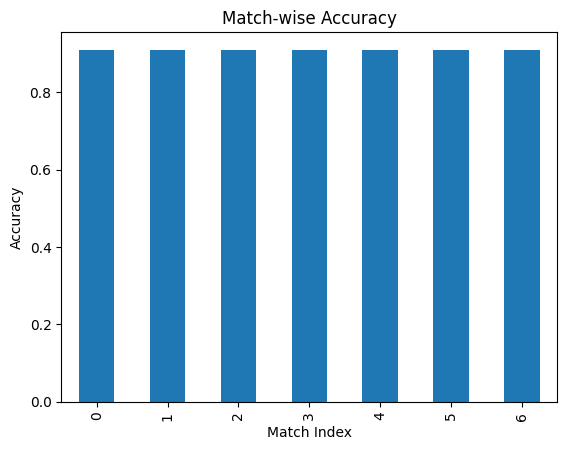

In [141]:

import matplotlib.pyplot as plt

plt.figure()
results_df["accuracy"].plot(kind="bar")
plt.title("Match-wise Accuracy")
plt.xlabel("Match Index")
plt.ylabel("Accuracy")
plt.show()